
Memulai Physics-Guided Training...

Epoch    1 | Physics Data Loss (MSE): nan
Epoch   10 | Physics Data Loss (MSE): nan
Epoch   20 | Physics Data Loss (MSE): nan
Epoch   30 | Physics Data Loss (MSE): nan
Epoch   40 | Physics Data Loss (MSE): nan
Epoch   50 | Physics Data Loss (MSE): nan
Epoch   60 | Physics Data Loss (MSE): nan
Epoch   70 | Physics Data Loss (MSE): nan
Epoch   80 | Physics Data Loss (MSE): nan
Epoch   90 | Physics Data Loss (MSE): nan
Epoch  100 | Physics Data Loss (MSE): nan
Epoch  110 | Physics Data Loss (MSE): nan
Epoch  120 | Physics Data Loss (MSE): nan
Epoch  130 | Physics Data Loss (MSE): nan
Epoch  140 | Physics Data Loss (MSE): nan
Epoch  150 | Physics Data Loss (MSE): nan
Epoch  160 | Physics Data Loss (MSE): nan
Epoch  170 | Physics Data Loss (MSE): nan
Epoch  180 | Physics Data Loss (MSE): nan
Epoch  190 | Physics Data Loss (MSE): nan
Epoch  200 | Physics Data Loss (MSE): nan
Epoch  210 | Physics Data Loss (MSE): nan
Epoch  220 | Physics Data Loss (MSE): n

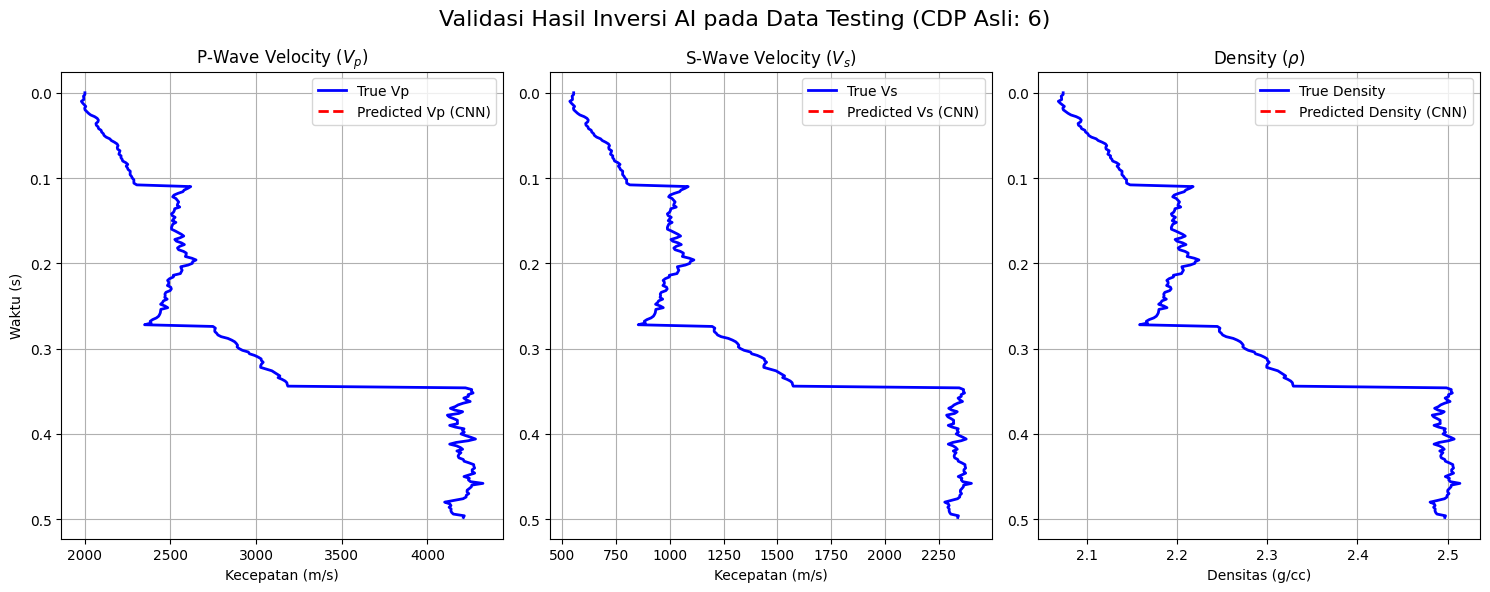

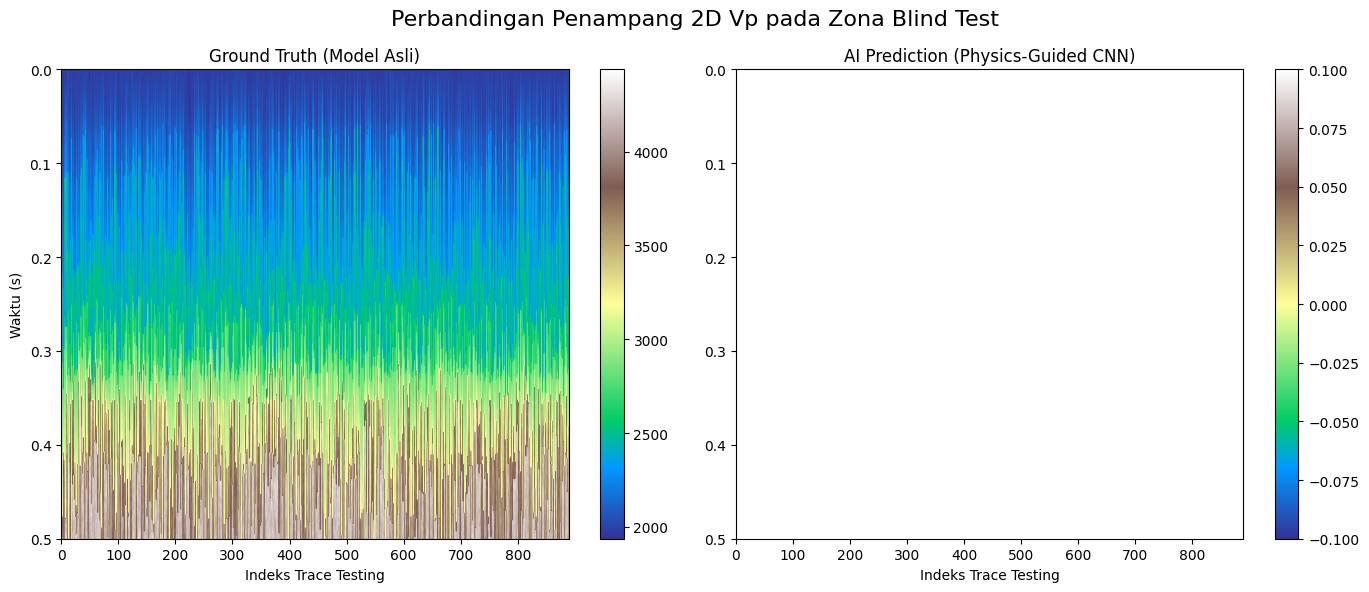

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =============================================================================
# 1. PERSIAPAN DATA
# =============================================================================
data = np.load('advanced_geology_dataset.npz')
seismic_all = data['seismic_gathers']  
low_freq_vp = data['vp_true']          
low_freq_vs = data['vs_true']
low_freq_rho = data['rho_true']
wavelets = data['wavelets']            
angles = data['angles']                

# PERBAIKAN: Menambahkan kembali definisi DT (Sampling rate 2 ms)
DT = 0.002 

NT, N_CDP, N_ANGLES = seismic_all.shape
WAV_LEN = wavelets.shape[1]

np.random.seed(42)
tf.random.set_seed(42)
cdp_indices = np.arange(N_CDP)
np.random.shuffle(cdp_indices)

train_size = int(0.2 * N_CDP)
train_indices = cdp_indices[:train_size]
test_indices = cdp_indices[train_size:]

X_train = tf.cast(seismic_all[:, train_indices, :], tf.float32)
X_train = tf.transpose(X_train, perm=[1, 0, 2]) 

# =============================================================================
# 2. ARSITEKTUR CNN (Perbaikan Warning Initializer)
# =============================================================================
def build_prestack_cnn(nt, n_angles, wav_len):
    input_layer = layers.Input(shape=(nt, n_angles))
    
    # Menggunakan string alias agar Keras membuat instansiasi baru per layer
    x = layers.Conv1D(filters=60, kernel_size=wav_len, strides=1, 
                      padding='same', activation='relu',
                      kernel_initializer='glorot_uniform', 
                      bias_initializer='zeros')(input_layer)
                      
    x = layers.Conv1D(filters=1, kernel_size=wav_len, strides=1, 
                      padding='same', activation='relu',
                      kernel_initializer='glorot_uniform', 
                      bias_initializer='zeros')(x)
                      
    x = layers.Flatten()(x)
    output_layer = layers.Dense(nt * 3, activation='linear', 
                                kernel_initializer='glorot_uniform', 
                                bias_initializer='zeros')(x)
    
    output_layer = layers.Reshape((nt, 3))(output_layer)
    
    model = models.Model(inputs=input_layer, outputs=output_layer, name="Physics_Guided_CNN")
    return model

cnn_model = build_prestack_cnn(NT, N_ANGLES, WAV_LEN)

# =============================================================================
# 3. PHYSICS FORWARD MODELING TENSORFLOW (Perbaikan Tipe Data)
# =============================================================================
@tf.function
def tf_aki_richards_and_convolve(pred_params, angles_tensor, wavelets_tensor):
    batch_size = tf.shape(pred_params)[0]
    vp = pred_params[:, :, 0]
    vs = pred_params[:, :, 1]
    rho = pred_params[:, :, 2]
    
    dvp = vp[:, 1:] - vp[:, :-1]
    dvs = vs[:, 1:] - vs[:, :-1]
    drho = rho[:, 1:] - rho[:, :-1]
    
    vp_avg = vp[:, :-1] + dvp / 2.0
    vs_avg = vs[:, :-1] + dvs / 2.0
    rho_avg = rho[:, :-1] + drho / 2.0
    
    vp_avg = tf.where(vp_avg == 0, 1e-8, vp_avg)
    vs_avg = tf.where(vs_avg == 0, 1e-8, vs_avg)
    rho_avg = tf.where(rho_avg == 0, 1e-8, rho_avg)
    
    A = 0.5 * (dvp/vp_avg + drho/rho_avg)
    B = 0.5 * (dvp/vp_avg) - 2.0 * tf.square(vs_avg/vp_avg) * (2.0*dvs/vs_avg + drho/rho_avg)
    C = 0.5 * (dvp/vp_avg)
    
    d_cal_list = []
    
    pi_factor = tf.constant(np.pi / 180.0, dtype=tf.float32)
    
    for i in range(len(angles)):
        theta_rad = angles_tensor[i] * pi_factor
        
        sin_t = tf.sin(theta_rad)
        tan_t = tf.tan(theta_rad)
        
        R = A + B * tf.square(sin_t) + C * tf.square(sin_t) * tf.square(tan_t)
        
        pad = tf.zeros((batch_size, 1), dtype=tf.float32)
        R_padded = tf.concat([pad, R], axis=1) 
        
        R_reshaped = tf.reshape(R_padded, [batch_size, NT, 1])
        
        wav = tf.cast(wavelets_tensor[i], tf.float32)
        wav = tf.reshape(wav, [WAV_LEN, 1, 1])
        
        trace_cal = tf.nn.conv1d(R_reshaped, wav, stride=1, padding='SAME')
        d_cal_list.append(tf.reshape(trace_cal, [batch_size, NT]))
        
    d_cal = tf.stack(d_cal_list, axis=-1)
    return d_cal

# =============================================================================
# 4. CUSTOM TRAINING LOOP 
# =============================================================================
learning_rate = 0.0001
batch_size = 32
epochs = 2000
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_dataset = train_dataset.shuffle(buffer_size=train_size).batch(batch_size)

print("\nMemulai Physics-Guided Training...\n")
angles_tf = tf.constant(angles, dtype=tf.float32)

for epoch in range(epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    
    for batch_data_obs in train_dataset:
        with tf.GradientTape() as tape:
            pred_model = cnn_model(batch_data_obs, training=True) 
            
            d_cal = tf_aki_richards_and_convolve(pred_model, angles_tf, wavelets)
            
            loss = tf.reduce_mean(tf.square(d_cal - batch_data_obs))
            
        gradients = tape.gradient(loss, cnn_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, cnn_model.trainable_variables))
        
        epoch_loss_avg.update_state(loss)
        
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:4d} | Physics Data Loss (MSE): {epoch_loss_avg.result().numpy():.6f}")

print("\nPelatihan selesai!")

# =============================================================================
# 5. VISUALISASI HASIL PREDIKSI (VALIDASI)
# =============================================================================
print("\nMenyiapkan visualisasi hasil pengujian...")

# 1. Menyiapkan Data Testing
X_test = tf.cast(seismic_all[:, test_indices, :], tf.float32)
X_test = tf.transpose(X_test, perm=[1, 0, 2])

# 2. Melakukan Prediksi
predicted_models = cnn_model.predict(X_test) 

# 3. Mengambil satu CDP acak dari data testing
test_idx = 10 
cdp_asli = test_indices[test_idx]

vp_pred = predicted_models[test_idx, :, 0]
vs_pred = predicted_models[test_idx, :, 1]
rho_pred = predicted_models[test_idx, :, 2]

vp_true = low_freq_vp[:, cdp_asli]
vs_true = low_freq_vs[:, cdp_asli]
rho_true = low_freq_rho[:, cdp_asli]

# Variabel DT sekarang sudah terdefinisi dan aman digunakan
time_axis = np.arange(NT) * DT

# Plot Perbandingan 1D
fig, ax = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(f'Validasi Hasil Inversi AI pada Data Testing (CDP Asli: {cdp_asli})', fontsize=16)

ax[0].plot(vp_true, time_axis, 'b-', label='True Vp', linewidth=2)
ax[0].plot(vp_pred, time_axis, 'r--', label='Predicted Vp (CNN)', linewidth=2)
ax[0].set_title('P-Wave Velocity ($V_p$)')
ax[0].set_ylabel('Waktu (s)')
ax[0].set_xlabel('Kecepatan (m/s)')
ax[0].invert_yaxis()
ax[0].legend()
ax[0].grid(True)

ax[1].plot(vs_true, time_axis, 'b-', label='True Vs', linewidth=2)
ax[1].plot(vs_pred, time_axis, 'r--', label='Predicted Vs (CNN)', linewidth=2)
ax[1].set_title('S-Wave Velocity ($V_s$)')
ax[1].set_xlabel('Kecepatan (m/s)')
ax[1].invert_yaxis()
ax[1].legend()
ax[1].grid(True)

ax[2].plot(rho_true, time_axis, 'b-', label='True Density', linewidth=2)
ax[2].plot(rho_pred, time_axis, 'r--', label='Predicted Density (CNN)', linewidth=2)
ax[2].set_title('Density ($\\rho$)')
ax[2].set_xlabel('Densitas (g/cc)')
ax[2].invert_yaxis()
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()

# =============================================================================
# OPTIONAL: Visualisasi Penampang 2D 
# =============================================================================
vp_pred_2d = predicted_models[:, :, 0].T  
vp_true_2d = low_freq_vp[:, test_indices]

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('Perbandingan Penampang 2D Vp pada Zona Blind Test', fontsize=16)

c1 = ax2[0].imshow(vp_true_2d, aspect='auto', cmap='terrain', extent=[0, len(test_indices), NT*DT, 0])
ax2[0].set_title('Ground Truth (Model Asli)')
ax2[0].set_ylabel('Waktu (s)')
ax2[0].set_xlabel('Indeks Trace Testing')
fig2.colorbar(c1, ax=ax2[0])

c2 = ax2[1].imshow(vp_pred_2d, aspect='auto', cmap='terrain', extent=[0, len(test_indices), NT*DT, 0])
ax2[1].set_title('AI Prediction (Physics-Guided CNN)')
ax2[1].set_xlabel('Indeks Trace Testing')
fig2.colorbar(c2, ax=ax2[1])

plt.tight_layout()
plt.show()